# Part 1c: Early Stopping
**Author:** Kalhar Mayurbhai Patel (019140511)

Demonstrates early stopping to prevent overfitting in TF and PyTorch.

In [1]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=1500, n_features=20, n_informative=8, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## TensorFlow: EarlyStopping Callback

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 22: early stopping
Restoring model weights from the end of the best epoch: 12.
Without ES: 200 epochs, Val Acc=0.8978
With ES:    22 epochs, Val Acc=0.9000


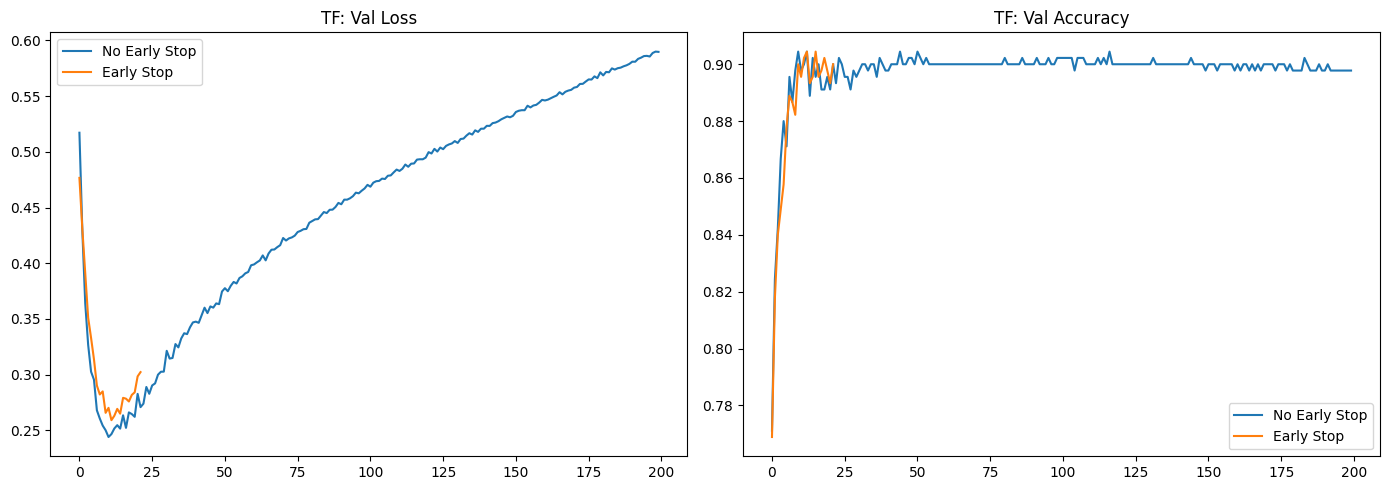

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential, callbacks

# Model WITHOUT early stopping
m1 = Sequential([layers.Dense(128, activation='relu', input_shape=(20,)),
                  layers.Dense(64, activation='relu'), layers.Dense(1, activation='sigmoid')])
m1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
h1 = m1.fit(X_train, y_train, epochs=200, batch_size=32,
            validation_data=(X_test, y_test), verbose=0)

# Model WITH early stopping
m2 = Sequential([layers.Dense(128, activation='relu', input_shape=(20,)),
                  layers.Dense(64, activation='relu'), layers.Dense(1, activation='sigmoid')])
m2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                     restore_best_weights=True, verbose=1)
h2 = m2.fit(X_train, y_train, epochs=200, batch_size=32,
            validation_data=(X_test, y_test), callbacks=[early_stop], verbose=0)

print(f"Without ES: {len(h1.history['loss'])} epochs, Val Acc={h1.history['val_accuracy'][-1]:.4f}")
print(f"With ES:    {len(h2.history['loss'])} epochs, Val Acc={h2.history['val_accuracy'][-1]:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(h1.history['val_loss'], label='No Early Stop')
ax[0].plot(h2.history['val_loss'], label='Early Stop')
ax[0].set_title('TF: Val Loss'); ax[0].legend()
ax[1].plot(h1.history['val_accuracy'], label='No Early Stop')
ax[1].plot(h2.history['val_accuracy'], label='Early Stop')
ax[1].set_title('TF: Val Accuracy'); ax[1].legend()
plt.tight_layout(); plt.show()

## PyTorch: Manual Early Stopping

Early stopping at epoch 21


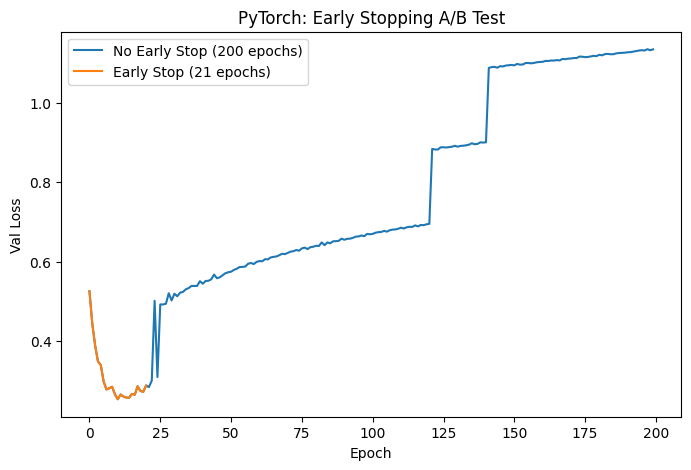

In [3]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dl = DataLoader(TensorDataset(torch.FloatTensor(X_train).to(device),
    torch.FloatTensor(y_train).unsqueeze(1).to(device)), batch_size=32, shuffle=True)
X_te = torch.FloatTensor(X_test).to(device)
y_te = torch.FloatTensor(y_test).unsqueeze(1).to(device)

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(20,128), nn.ReLU(),
                                 nn.Linear(128,64), nn.ReLU(),
                                 nn.Linear(64,1), nn.Sigmoid())
    def forward(self, x): return self.net(x)

# Early stopping implementation
class EarlyStopping:
    def __init__(self, patience=10):
        self.patience = patience
        self.counter = 0
        self.best_loss = float('inf')
        self.best_state = None
        self.stop = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

# Train with early stopping
torch.manual_seed(42)
model = Net().to(device)
opt = torch.optim.Adam(model.parameters())
crit = nn.BCELoss()
es = EarlyStopping(patience=10)
losses_es = []

for ep in range(200):
    model.train()
    for xb, yb in dl:
        opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        vl = crit(model(X_te), y_te).item()
    losses_es.append(vl)
    es.step(vl, model)
    if es.stop:
        print(f"Early stopping at epoch {ep+1}")
        model.load_state_dict(es.best_state)
        break

# Train without early stopping
torch.manual_seed(42)
model2 = Net().to(device)
opt2 = torch.optim.Adam(model2.parameters())
losses_no = []
for ep in range(200):
    model2.train()
    for xb, yb in dl:
        opt2.zero_grad(); crit(model2(xb), yb).backward(); opt2.step()
    model2.eval()
    with torch.no_grad():
        losses_no.append(crit(model2(X_te), y_te).item())

plt.figure(figsize=(8, 5))
plt.plot(losses_no, label='No Early Stop (200 epochs)')
plt.plot(losses_es, label=f'Early Stop ({len(losses_es)} epochs)')
plt.xlabel('Epoch'); plt.ylabel('Val Loss'); plt.legend()
plt.title('PyTorch: Early Stopping A/B Test'); plt.show()

## Key Points
- Early stopping monitors validation loss and halts when it stops improving
- `patience` controls how many epochs to wait for improvement before stopping
- `restore_best_weights=True` reverts to the checkpoint with lowest val loss
- Saves compute time and prevents overfitting automatically